# Basic spatial transcriptomics pre-processing with Sopa

In this first notebook, we will work on synthetic cell data to get the basics of data pre-processing with [Sopa](https://github.com/prism-oncology/sopa).

> ℹ️ Reminder: Sopa is built on top of [SpatialData](https://spatialdata.scverse.org/en/stable/). Feel free to check their [documentation](https://spatialdata.scverse.org/en/stable/) if you're new with this framework.


## Dependencies

For this tutorial, we'll need Sopa as well as Cellpose. Below, we use `cellpose<4` which is faster and therefore more convenient for a quick workshop, but Sopa also works with `cellpose>=4`.


In [ ]:
!pip install 'sopa[cellpose]' 'cellpose<4.0.0'

## Toy SpatialData object

We can create a synthetic dataset via `sopa`, which will create a `SpatialData` object. We often use "`sdata`" to denote an instance of the `SpatialData` class.


In [3]:
import sopa

sdata = sopa.io.toy_dataset()

[INFO] (sopa.utils.data) Image of size (4, 2048, 2048) with 400 cells and 100 transcripts per cell


This object contains two images (`image` and `he_image`), points (`misc` and `transcripts`) and shapes (`cells`).


In [4]:
sdata

SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 1024, 1024), (3, 512, 512), (3, 256, 256)
│     └── 'image': DataArray[cyx] (4, 2048, 2048)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 5) (2D points)
└── Shapes
      └── 'cells': GeoDataFrame shape: (400, 1) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), image (Images), transcripts (Points), cells (Shapes)
    ▸ 'microns', with elements:
        transcripts (Points)

For example, to access the `transcripts` element, simply use square brackets (as with dictionaries).


In [5]:
sdata["transcripts"]

,x,y,z_stack,genes,cell_id
npartitions=1,,,,,
0,float64,float64,int64,category[known],int64
39999,...,...,...,...,...


We can see that these transcripts are a `DataFrame` [Dask](https://docs.dask.org/en/stable/). This is an extension of `pandas`, which allows lazy-loading, i.e. never loading data into memory until it's needed.

To "see" the data itself, you can use `.compute()`, which will return a pandas `DataFrame`:


In [6]:
sdata["transcripts"].compute()

,x,y,z_stack,genes,cell_id
0,111.111505,610.189298,1,EPCAM,1
1,109.002042,607.359920,1,EPCAM,1
2,110.386745,607.485343,-1,CXCL1,1
3,107.789506,611.847764,0,EPCAM,0
4,108.777584,611.540180,0,EPCAM,1
...,...,...,...,...,...
39995,295.752531,801.737126,-1,CD20,400
39996,295.986610,801.250840,-1,CD20,400
39997,296.716232,800.426979,0,CD20,400
39998,295.227573,803.195543,0,CD20,400


You can also use `.attrs` to access the metadata of this dataframe. For example, `attrs` contain a `transform` dictionary of transformations.

> **_Question:_** What is the intrinsic transcript coordinate system here?


In [7]:
sdata["transcripts"].attrs

{'spatialdata_attrs': {'feature_key': 'genes'}, 'transform': {'global': Affine (x, y -> x, y)
    [   10.     0. -1000.]
    [    0.    10. -6000.]
    [0. 0. 1.], 'microns': Identity }}

We can also see that we already have cells. But, in real life, we have to segment them. That's what we'll be doing later in this tutorial.


In [8]:
sdata["cells"]

,geometry
0,"POLYGON ((120.097 86.433, 114.678 78.322, 106...."
1,"POLYGON ((207.097 54.433, 201.678 46.322, 193...."
2,"POLYGON ((317.097 20.433, 311.678 12.322, 303...."
3,"POLYGON ((417.097 53.433, 411.678 45.322, 403...."
4,"POLYGON ((433.097 25.433, 427.678 17.322, 419...."
...,...
395,"POLYGON ((1567.097 1940.433, 1561.678 1932.322..."
396,"POLYGON ((1760.097 2023.433, 1754.678 2015.322..."
397,"POLYGON ((1779.097 1935.433, 1773.678 1927.322..."
398,"POLYGON ((1962.097 1964.433, 1956.678 1956.322..."


Images can also be accessed. These are `xarray.DataArray` objects.

One of the many advantages of [`xarray`](https://docs.xarray.dev/en/stable/) is that you can name each channel. We also know the order of the dimensions (here, `y` then `x`). So you don't get lost...

> **_Question:_** What are the channels in this image? Which cell population(s) do these markers correspond to?


In [9]:
sdata["image"]

<xarray.DataArray 'image' (c: 4, y: 2048, x: 2048)> Size: 17MB
dask.array<array, shape=(4, 2048, 2048), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U4 64B 'DAPI' 'CK' 'CD3' 'CD20'
  * y        (y) float64 16kB 0.5 1.5 2.5 3.5 ... 2.046e+03 2.046e+03 2.048e+03
  * x        (x) float64 16kB 0.5 1.5 2.5 3.5 ... 2.046e+03 2.046e+03 2.048e+03
Attributes:
    transform:  {'global': Identity }

For example, with `xarray` you can easily select a channel by name, instead of having to remember that `DAPI` corresponds to index `0`. This can help avoid errors, and makes the code easier to read.


In [10]:
dapi_image = sdata["image"].sel(c="DAPI")
dapi_image

<xarray.DataArray 'image' (y: 2048, x: 2048)> Size: 4MB
dask.array<getitem, shape=(2048, 2048), dtype=uint8, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 16kB 0.5 1.5 2.5 3.5 ... 2.046e+03 2.046e+03 2.048e+03
  * x        (x) float64 16kB 0.5 1.5 2.5 3.5 ... 2.046e+03 2.046e+03 2.048e+03
    c        <U4 16B 'DAPI'
Attributes:
    transform:  {'global': Identity }

As with transcripts, we don't have the image values, but only an "abstract view" of the image and its metadata. To get a numpy array, you can use `to_numpy`:


In [11]:
dapi_image_numpy = dapi_image.to_numpy()

This image can be segmented using Cellpose. To do this, we'll first download a pre-trained model:


In [12]:
from cellpose import models

model = models.Cellpose(model_type="cyto3")

We then apply this model to our DAPI image. We specify the "expected" cell diameter in pixels.


In [13]:
mask, *_ = model.eval(dapi_image_numpy, diameter=30, channels=[0, 0])

/Users/quentinblampey/miniforge3/envs/workshop1/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


This `mask` is a `numpy` array and can be displayed easily via `matplotlib`:


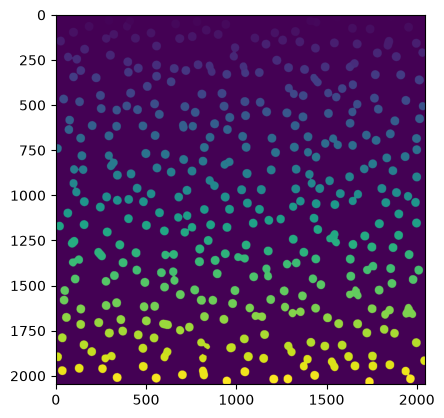

In [14]:
import matplotlib.pyplot as plt

plt.imshow(mask)

In fact, to get things right, there are a few extra operations you can perform:

- Image pre-processing: apply operations to facilitate segmentation, such as normalization or contrast enhancement.
- Patches: when images are too large, you can't run Cellpose on the whole image, due to the RAM usage. In practice, you "slice" the image into lots of small patches, then run Cellpose on each patch.
- Resolving conflicts: patch-based segmentation can lead to artifacts at patch boundaries. These conflicts need to be resolved to ensure clean segmentation.
- Vectorization: An optimized way of manipulating segmentation is through the use of polygons. Creating polygons from an image is called vectorization.

[Sopa](https://github.com/prism-oncology/sopa) handles all this natively, and adds a few other features (parallelization, filters, region of interest, etc.).

The image below summarizes the different stages of Sopa:

<img src="https://raw.githubusercontent.com/prism-oncology/sopa/master/docs/assets/overview_white.png" style="max-width:1000px;width:100%"/>

For instance, to run cellpose via `sopa`:


In [15]:
# we make patches
sopa.make_image_patches(sdata, patch_width=1200)

# we run cellpose
sopa.segmentation.cellpose(sdata, channels="DAPI", diameter=30)

[INFO] (sopa.patches.patches) Added 4 patch(es) to sdata['image_patches']
[WARNING] (sopa._settings) Running without parallelization backend can be slow. Consider using a backend, e.g. via `sopa.settings.parallelization_backend = 'dask'`, or `export SOPA_PARALLELIZATION_BACKEND=dask`.
100%|██████████| 4/4 [00:30<00:00,  7.53s/it]
[INFO] (sopa.segmentation.stainings) Found 412 total cells
Resolving conflicts: 100%|██████████| 340/340 [00:00<00:00, 21027.80it/s]
[INFO] (sopa.segmentation.stainings) Added 371 cell boundaries in sdata['cellpose_boundaries']


Now we have the predictions directly as a [GeoPandas](https://geopandas.org/en/stable/docs.html) DataFrame of polygons. They are accessible in the `SpatialData` object, under the name `"cellpose_boundaries"`.


In [16]:
sdata["cellpose_boundaries"]

,geometry
image0,"POLYGON ((1371.029 39.392, 1376.845 56.08, 138..."
image1,"POLYGON ((1520.046 20.414, 1525.921 36.226, 15..."
image2,"POLYGON ((1818.683 6.371, 1821.845 25.08, 1828..."
image3,"POLYGON ((1915.051 63.567, 1914.525 70.887, 19..."
image4,"POLYGON ((1605.5 64.833, 1604.565 79.169, 1607..."
...,...
image495,"POLYGON ((1150.585 1570.74, 1150.851 1579.412,..."
image496,"POLYGON ((1076.567 1693.067, 1083.774 1699.08,..."
image497,"POLYGON ((1119.64 1784.495, 1122.773 1791.933,..."
image498,"POLYGON ((1111.565 1906.173, 1116.11 1922.506,..."


Next, we can count the transcripts in each cell, as we did in the previous tutorial.

To do that, we can use `sopa.aggregate`. It uses lazy-loading, can also aggregate channels, perform some QC/filters, etc.


In [17]:
sopa.aggregate(sdata)

[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 371 cells


[########################################] | 100% Completed | 105.22 ms


[INFO] (sopa.aggregation.channels) Aggregating channels intensity over 371 cells with mode='average'


[########################################] | 100% Completed | 315.50 ms


[INFO] (sopa.aggregation.aggregation) 0 cell(s) not passing filtering due to mean channel intensity < 6.18


This aggregation will create an [`AnnData`](https://anndata.readthedocs.io/en/stable/) table of size `#cell` x `#genes`.


In [18]:
adata = sdata["table"]
adata

AnnData object with n_obs × n_vars = 371 × 5
    obs: 'region', 'slide', 'cell_id', 'area'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'spatial', 'intensities'

We can see that we also have information for each cell in `adata.obs`, such as the area of each cell (`area`).


In [19]:
adata.obs

,region,slide,cell_id,area
aaaaaaaa-1,cellpose_boundaries,image,aaaaaaaa-1,7010.204137
aaaaaaab-1,cellpose_boundaries,image,aaaaaaab-1,3363.737724
aaaaaaac-1,cellpose_boundaries,image,aaaaaaac-1,2975.443558
aaaaaaad-1,cellpose_boundaries,image,aaaaaaad-1,4653.401347
aaaaaaae-1,cellpose_boundaries,image,aaaaaaae-1,4693.672886
...,...,...,...,...
aaaaabgo-1,cellpose_boundaries,image,aaaaabgo-1,4847.823749
aaaaabgp-1,cellpose_boundaries,image,aaaaabgp-1,6794.521517
aaaaabha-1,cellpose_boundaries,image,aaaaabha-1,4595.910175
aaaaabhb-1,cellpose_boundaries,image,aaaaabhb-1,4777.155513


To access the counts themselves, you need to use `adata.X`, which is a `scipy` sparse matrix.


In [20]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1838 stored elements and shape (371, 5)>

To see the counts and the corresponding gene names, you can use `adata.to_df()` to convert it into `DataFrame` pandas:


In [21]:
adata.to_df()

,CD20,CD3E,CXCL1,CXCL4,EPCAM
aaaaaaaa-1,147,14,17,14,7
aaaaaaab-1,2,9,7,4,75
aaaaaaac-1,1,80,7,7,3
aaaaaaad-1,5,80,7,0,8
aaaaaaae-1,7,82,6,1,4
...,...,...,...,...,...
aaaaabgo-1,4,5,0,7,84
aaaaabgp-1,160,6,11,12,11
aaaaabha-1,77,5,8,2,7
aaaaabhb-1,81,8,3,2,5


You can also display cells in space, and color them by their transcriptomic expression.

> NB: we could display polygons, but here for simplicity we display cell centroids (`spot_size` is the radius of the spot / circle used to represent each cell). You can also use [`squidpy`](https://squidpy.readthedocs.io/en/stable/) for such plots, but we didn't do it here as it's not one of Sopa's dependencies.


/var/folders/9h/vzx8b9wd0qv5vvb6l1lk3rnc0000gn/T/ipykernel_49853/1412945128.py:3: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=adata.var_names, spot_size=80, ncols=3)


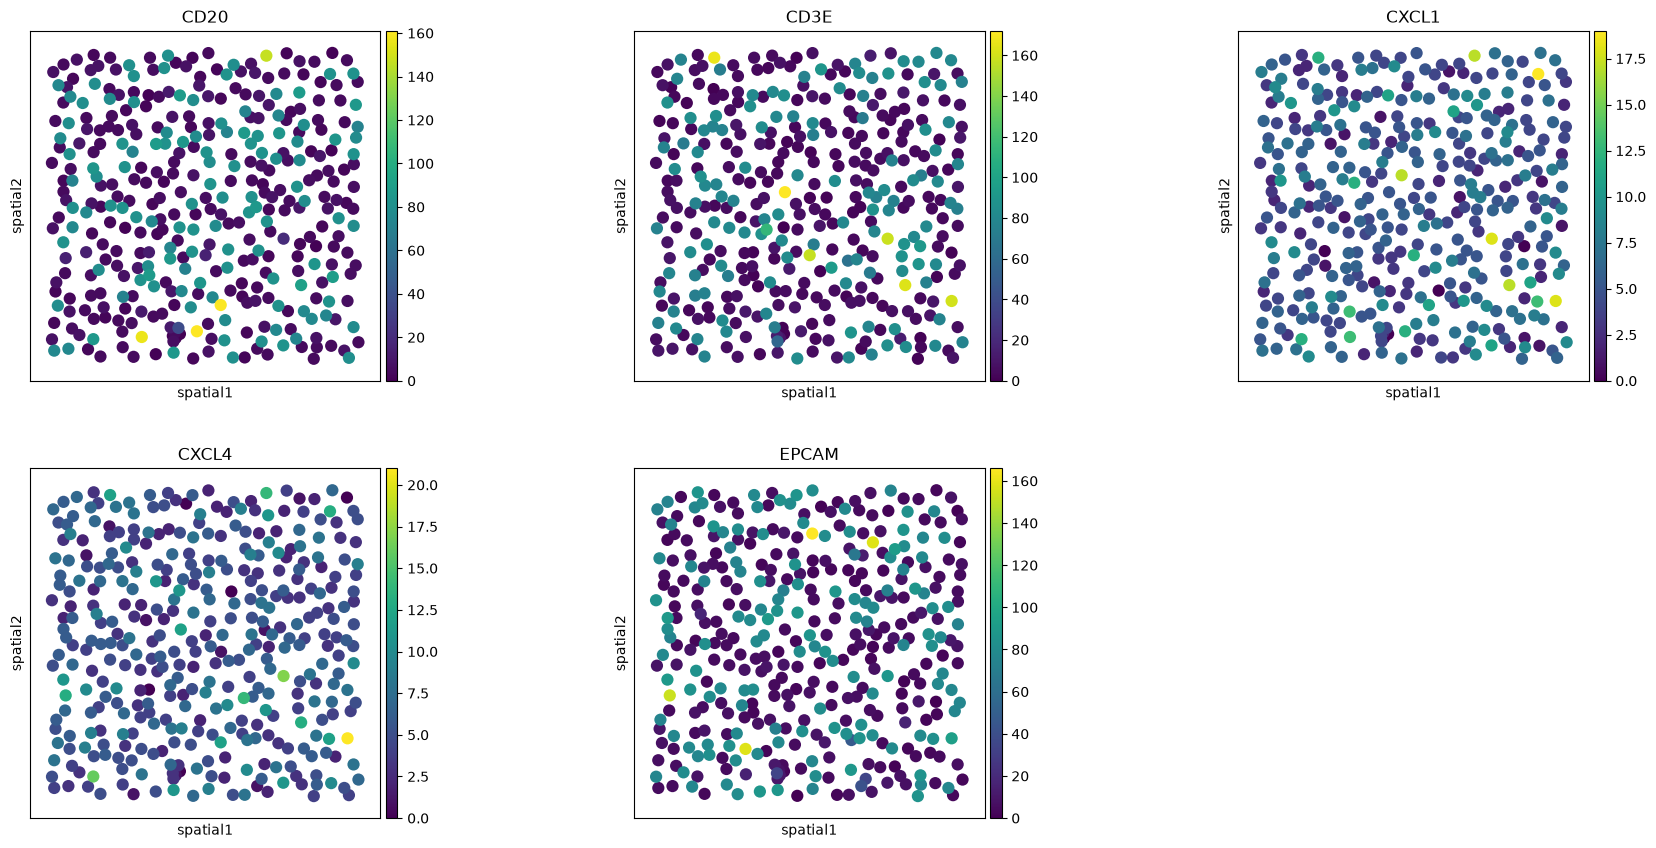

In [22]:
import scanpy as sc

sc.pl.spatial(adata, color=adata.var_names, spot_size=80, ncols=3)

We can also access the average intensity of each channel in the image in each cell:


In [23]:
adata.obsm["intensities"]

,DAPI,CK,CD3,CD20
aaaaaaaa-1,124.060666,0.000000,0.000000,124.060666
aaaaaaab-1,118.314464,118.314464,0.000000,0.000000
aaaaaaac-1,114.569561,0.000000,114.569561,0.000000
aaaaaaad-1,106.625563,0.000000,106.625563,0.000000
aaaaaaae-1,105.768134,0.000000,105.768134,0.000000
...,...,...,...,...
aaaaabgo-1,102.294590,102.294590,0.000000,0.000000
aaaaabgp-1,131.172992,0.000000,0.000000,131.172992
aaaaabha-1,108.012166,0.000000,0.000000,108.012166
aaaaabhb-1,103.954631,0.000000,0.000000,103.954631


### Static (non-interactive) visualization

Using [`spatialdata_plot`](https://spatialdata.scverse.org/projects/plot/en/latest/plotting.html), we can display our SpatialData object directly in the notebook. Here, we show the cell segmentation, as well as the image itself.

> **_Question:_** Look at the segmentation. Why do you think this segmentation is not correct everywhere? What would be a better approach?


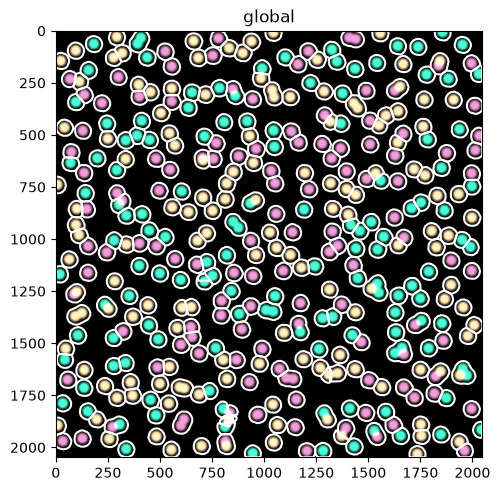

In [24]:
import spatialdata_plot

sdata.pl.render_images("image").pl.render_shapes(
    "cellpose_boundaries", fill_alpha=0, outline_alpha=1, outline_color="#FFFFFF"
).pl.show("global")

## Recommended improvements

### Other segmentation methods

Here, Cellpose was used to segment cells from DAPI. So we didn't use transcript information. Other segmentation tools such as Baysor or Proseg could have been used for better segmentation. See the [Sopa documentation](https://prism-oncology.github.io/sopa/api/segmentation/).

### Visualization

Here, we used `spatialdata-plot` for the visualization, which is static (i.e., non-interactive). In general, when we have large images, we prefer interactive visualizations. For this, we can use [`napari-spatialdata`](https://github.com/scverse/napari-spatialdata). If you have Xenium data, we also recommend using the Xenium Explorer, which [interoperates well with Sopa](https://prism-oncology.github.io/sopa/tutorials/xenium_explorer/explorer/).

### Aggregation

By default, the channel aggregation is a simple channel intensity average within the cell boundary. This can incorporate a lot of noise within the cell-by-protein table. Other aggregations can be used such as [`sopa.aggregation.nimbus`](https://prism-oncology.github.io/sopa/api/aggregation/#sopa.aggregation.nimbus).

## Real usage

For real world scenario, please check the [official documentation](https://prism-oncology.github.io/sopa/) to see the full list of supported technologies, segmentation methods, and all the features that were not mentioned in this notebook (feel free to explore the docs!).

> ℹ️ If you're familiar with Nextflow and/or Docker, you may be interested in `nf-core/sopa`: see [this repo](https://github.com/nf-core/sopa) and the corresponding [usage guide](https://nf-co.re/sopa/usage).
